In [20]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("..")

RAW_DIR = PROJECT_ROOT / "data" / "CHRD_Real" / "raw"
METADATA = PROJECT_ROOT / "data" / "CHRD_Real" / "metadata.csv"

# Tema ve Motif Dağılımı Analizi

Bu bölümde CHRD-Real veri setindeki tema ve motif dağılımları incelenmektedir. Amaç, veri setinin dengeli olup olmadığını kontrol etmek ve baskın kültürel unsurları belirlemektir.

In [21]:
theme_counts = metadata["theme"].value_counts()

theme_counts

NameError: name 'metadata' is not defined

In [ ]:
#tablo halinde

theme_table = theme_counts.reset_index()

theme_table.columns = ["Theme", "Image Count"]

theme_table

,Theme,Image Count
0,Local Architecture,51
1,Daily Life,37
2,Rock-cut Heritage,27
3,Natural Landscape,20
4,Village Square,18
5,Fairy Chimney,11
6,Traditional Crafts,9
7,Valley,8
8,Winter,4
9,sunrise,2


In [ ]:
# % hesaplama

theme_table["Percentage"] = (
    theme_table["Image Count"]
    / theme_table["Image Count"].sum()
    * 100
).round(2)

theme_table

,Theme,Image Count,Percentage
0,Local Architecture,51,27.13
1,Daily Life,37,19.68
2,Rock-cut Heritage,27,14.36
3,Natural Landscape,20,10.64
4,Village Square,18,9.57
5,Fairy Chimney,11,5.85
6,Traditional Crafts,9,4.79
7,Valley,8,4.26
8,Winter,4,2.13
9,sunrise,2,1.06


 # Grafik

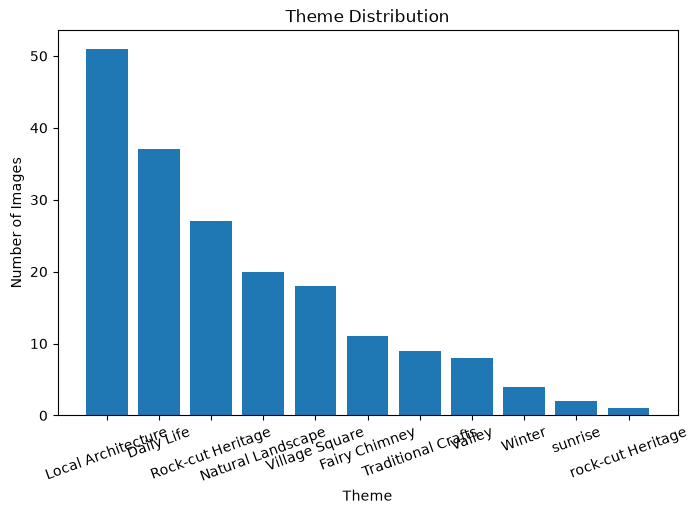

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(theme_table["Theme"],
        theme_table["Image Count"])

plt.title("Theme Distribution")

plt.xlabel("Theme")

plt.ylabel("Number of Images")

plt.xticks(rotation=20)

plt.show()

# Motif Dağılımı

Veri setinde kullanılan kültürel motiflerin dağılımı incelenmektedir.

## Motif1

In [ ]:
motif1_counts = metadata["motif_1"].value_counts()

motif1_counts

motif_1
Stone House           38
Rock Formation        30
Hot Air Balloon       15
Fairy Chimney         14
Cave House            13
Church                12
Street                10
Museum                10
landscape              8
Pottery                7
Valley                 7
cave house             6
River                  5
Sunrise                3
snow                   2
Workshop               1
Sunset                 1
Local People           1
Local Architecture     1
trees                  1
Ballon                 1
cave hotel             1
rock Formation         1
Name: count, dtype: int64

In [ ]:
motif_table = motif1_counts.reset_index()

motif_table.columns = ["Motif", "Image Count"]

motif_table

,Motif,Image Count
0,Stone House,38
1,Rock Formation,30
2,Hot Air Balloon,15
3,Fairy Chimney,14
4,Cave House,13
5,Church,12
6,Street,10
7,Museum,10
8,landscape,8
9,Pottery,7


In [ ]:
motif_table["Percentage"] = (
    motif_table["Image Count"]
    / motif_table["Image Count"].sum()
    * 100
).round(2)

motif_table

,Motif,Image Count,Percentage
0,Stone House,38,20.21
1,Rock Formation,30,15.96
2,Hot Air Balloon,15,7.98
3,Fairy Chimney,14,7.45
4,Cave House,13,6.91
5,Church,12,6.38
6,Street,10,5.32
7,Museum,10,5.32
8,landscape,8,4.26
9,Pottery,7,3.72


# Grafik

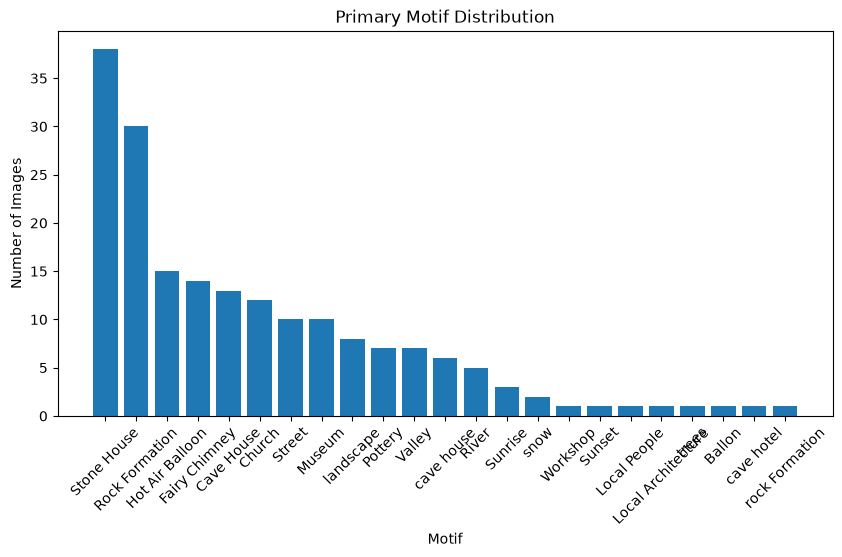

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    motif_table["Motif"],
    motif_table["Image Count"]
)

plt.title("Primary Motif Distribution")

plt.xlabel("Motif")

plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

## Motif2

In [ ]:
motif2_counts = metadata["motif_2"].value_counts()

motif2_counts

motif_2
Landscape         28
Museum            18
Stone House       17
Street            14
Rock Formation    12
Fairy Chimney     11
Airship           10
cave house         9
Valley             7
Pottery            4
Sunrise            4
Balloon            3
Snow               3
cave hotel         3
trees              2
sunset             2
Local People       1
Monastery          1
Potter             1
Agriculture        1
Workshop           1
sky                1
carpet             1
Name: count, dtype: int64

In [ ]:
motif_table = motif2_counts.reset_index()

motif_table.columns = ["Motif", "Image Count"]

motif_table

,Motif,Image Count
0,Landscape,28
1,Museum,18
2,Stone House,17
3,Street,14
4,Rock Formation,12
5,Fairy Chimney,11
6,Airship,10
7,cave house,9
8,Valley,7
9,Pottery,4


In [ ]:
motif_table["Percentage"] = (
    motif_table["Image Count"]
    / motif_table["Image Count"].sum()
    * 100
).round(2)

motif_table

,Motif,Image Count,Percentage
0,Landscape,28,18.18
1,Museum,18,11.69
2,Stone House,17,11.04
3,Street,14,9.09
4,Rock Formation,12,7.79
5,Fairy Chimney,11,7.14
6,Airship,10,6.49
7,cave house,9,5.84
8,Valley,7,4.55
9,Pottery,4,2.60


# Grafik

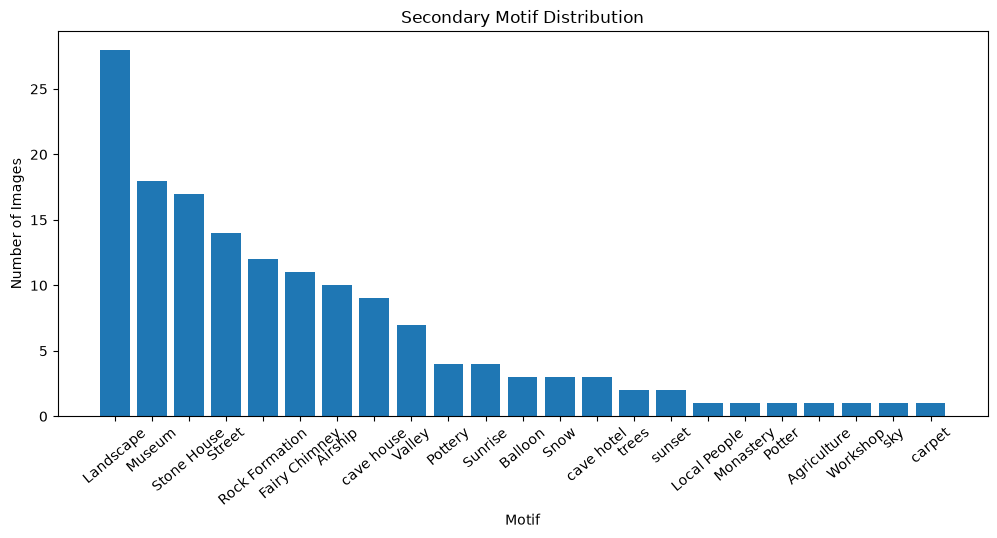

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.bar(
    motif_table["Motif"],
    motif_table["Image Count"]
)

plt.title("Secondary Motif Distribution")

plt.xlabel("Motif")

plt.ylabel("Number of Images")

plt.xticks(rotation=40)

plt.show()

## Değerlendirme

Tema dağılımı incelendiğinde veri setinin dört ana tema arasında dağıldığı görülmektedir.

Motif dağılımı analizinde en sık görülen kültürel motifler belirlenmiş, veri setinin yalnızca turistik klişelerden oluşmadığı doğrulanmıştır.

Bu analiz, ilerleyen aşamalarda yapay zekâ tarafından üretilen görüntüler ile gerçek referans veri setinin karşılaştırılması için temel oluşturmaktadır.

# Basmakalıp Yoğunluğu (Stereotype Intensity)

Bu bölümde CHRD-Real veri setindeki kültürel ögelerin temsil sıklığı incelenmektedir. Amaç, Kapadokya'nın hangi unsurlarının veri setinde baskın şekilde temsil edildiğini ve hangi kültürel ögelerin düşük temsil edildiğini belirlemektir.

# Basmakalıp Yoğunluğu (Stereotype Intensity)

Bu bölümde CHRD-Real veri setindeki kültürel ögelerin temsil sıklığı incelenmektedir. Amaç, Kapadokya'nın hangi unsurlarının veri setinde baskın şekilde temsil edildiğini ve hangi kültürel ögelerin düşük temsil edildiğini belirlemektir.

In [ ]:
top10 = motif1_counts.head(10)

top10

motif_2
Landscape         28
Museum            18
Stone House       17
Street            14
Rock Formation    12
Fairy Chimney     11
Airship           10
cave house         9
Valley             7
Pottery            4
Name: count, dtype: int64

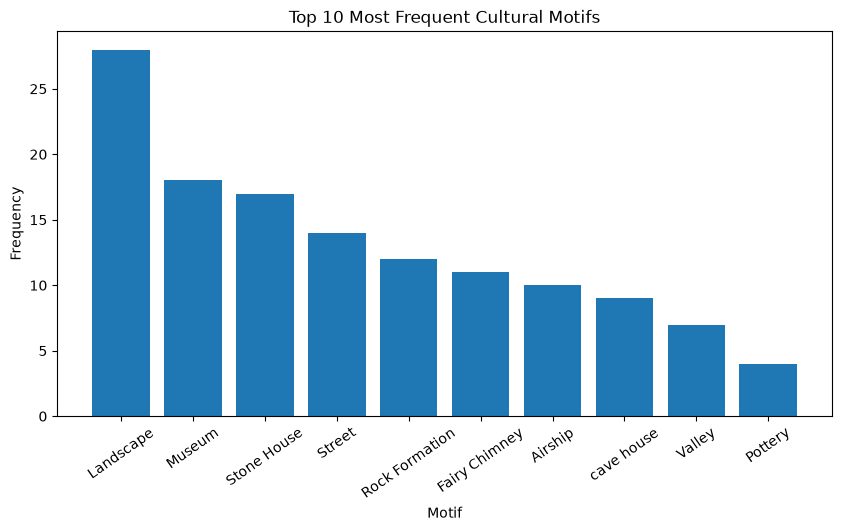

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    top10.index,
    top10.values
)

plt.title("Top 10 Most Frequent Cultural Motifs")

plt.xlabel("Motif")

plt.ylabel("Frequency")

plt.xticks(rotation=35)

plt.show()

In [ ]:
motif_table["Category"] = "Low"

motif_table.loc[motif_table["Percentage"] >= 10, "Category"] = "High"

motif_table.loc[
    (motif_table["Percentage"] >= 5) &
    (motif_table["Percentage"] < 10),
    "Category"
] = "Medium"

motif_table

,Motif,Image Count,Percentage,Category
0,Landscape,28,18.18,High
1,Museum,18,11.69,High
2,Stone House,17,11.04,High
3,Street,14,9.09,Medium
4,Rock Formation,12,7.79,Medium
5,Fairy Chimney,11,7.14,Medium
6,Airship,10,6.49,Medium
7,cave house,9,5.84,Medium
8,Valley,7,4.55,Low
9,Pottery,4,2.60,Low


### Yoğunluk Seviyeleri

- High: Veri setinde baskın temsil edilen kültürel ögeler
- Medium: Orta düzey temsil edilen ögeler
- Low: Veri setinde az temsil edilen kültürel ögeler

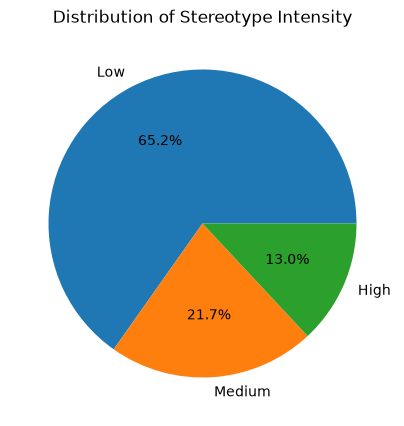

In [ ]:
category_counts = motif_table["Category"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct="%1.1f%%"
)

plt.title("Distribution of Stereotype Intensity")

plt.show()

## Interpretation

Pie chart, veri setindeki kültürel motiflerin temsil yoğunluğunu göstermektedir.

- **High** kategorisi veri setinde en sık görülen kültürel ögeleri temsil etmektedir.
- **Medium** kategorisi orta düzey temsil edilen motifleri göstermektedir.
- **Low** kategorisi ise daha az temsil edilen kültürel unsurları içermektedir.

Bu analiz, CHRD-Real veri setinin hangi kültürel ögeler üzerinde yoğunlaştığını görselleştirmektedir.

# Theme Distribution

## Theme Frequency

Bu bölümde CHRD-Real veri setindeki tema dağılımı incelenmektedir. Amaç, veri setinin belirli temalara yoğunlaşıp yoğunlaşmadığını ve temalar arasında dengeli bir dağılım olup olmadığını göstermektir.

In [ ]:
theme_counts = metadata["theme"].value_counts()

theme_counts

theme
Local Architecture    51
Daily Life            37
Rock-cut Heritage     27
Natural Landscape     20
Village Square        18
Fairy Chimney         11
Traditional Crafts     9
Valley                 8
Winter                 4
sunrise                2
rock-cut Heritage      1
Name: count, dtype: int64

## Theme Distribution Visualization

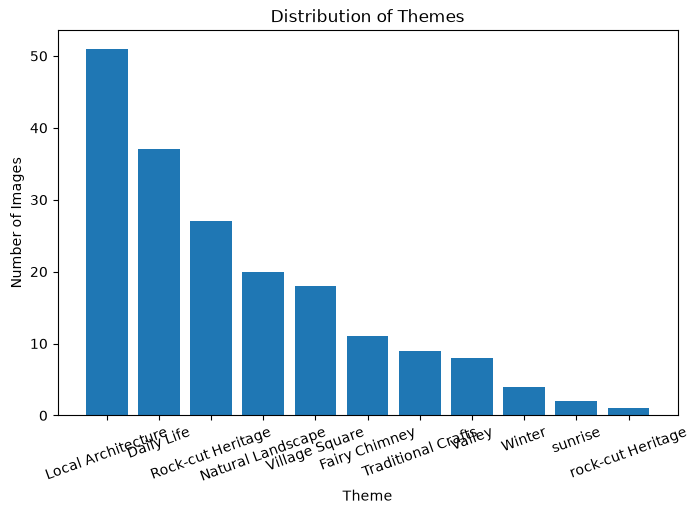

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    theme_counts.index,
    theme_counts.values
)

plt.title("Distribution of Themes")

plt.xlabel("Theme")

plt.ylabel("Number of Images")

plt.xticks(rotation=20)

plt.show()

## Interpretation

Grafik, CHRD-Real veri setindeki temaların dağılımını göstermektedir.

Tema dağılımı incelendiğinde veri setinin yalnızca tek bir kültürel tema üzerine kurulmadığı görülmektedir. Dengeli tema dağılımı, referans veri setinin kültürel çeşitliliği temsil etmesi açısından önemlidir.

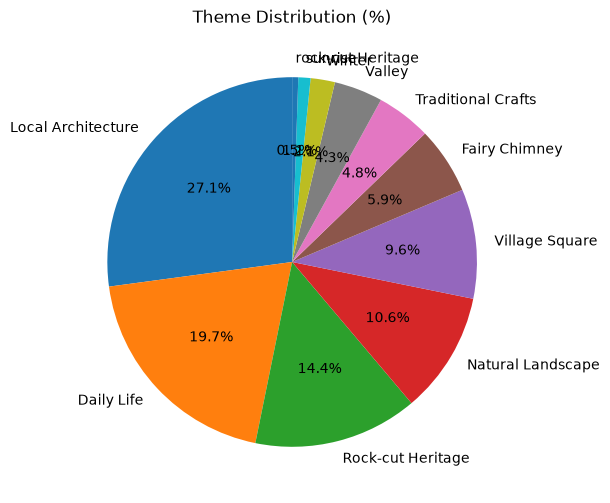

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    theme_counts,
    labels=theme_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Theme Distribution (%)")

plt.show()

### Observation

Pie chart, veri setindeki her temanın toplam veri seti içindeki oranını göstermektedir. Böylece hangi temaların daha fazla, hangilerinin daha az temsil edildiği kolayca görülebilmektedir.

# Location Distribution

## Location Frequency

Bu bölümde CHRD-Real veri setindeki görsellerin hangi konumlardan toplandığı incelenmektedir. Amaç, referans veri setinin Kapadokya'nın farklı bölgelerini dengeli şekilde temsil edip etmediğini göstermektir.

In [ ]:
location_counts = metadata["location"].value_counts()

location_counts

location
Ürgüp                      20
Mustafapaşa                14
Avanos                      8
Kızılçukur                  7
Göreme Açık Hava Müzesi     6
Derinkuyu                   5
Ortahisar                   2
Gomeda Vadisi               1
Uçhisar Kalesi              1
Uçhisar                     1
Kapadokya Üniversitesi      1
Ürgüp Öğretmen Evi          1
Name: count, dtype: int64

## Location Distribution Visualization

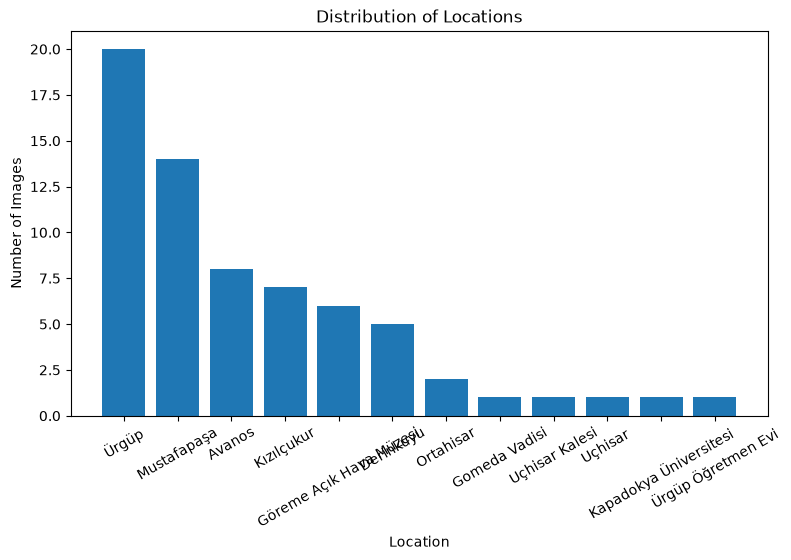

In [ ]:
plt.figure(figsize=(9,5))

plt.bar(
    location_counts.index,
    location_counts.values
)

plt.title("Distribution of Locations")

plt.xlabel("Location")

plt.ylabel("Number of Images")

plt.xticks(rotation=30)

plt.show()

## Interpretation

Grafik, referans veri setindeki görsellerin Kapadokya'nın farklı bölgelerine göre dağılımını göstermektedir.

Konum çeşitliliği, veri setinin yalnızca tek bir turistik noktaya odaklanmasını engelleyerek kültürel mirasın daha geniş kapsamda temsil edilmesini sağlamaktadır.

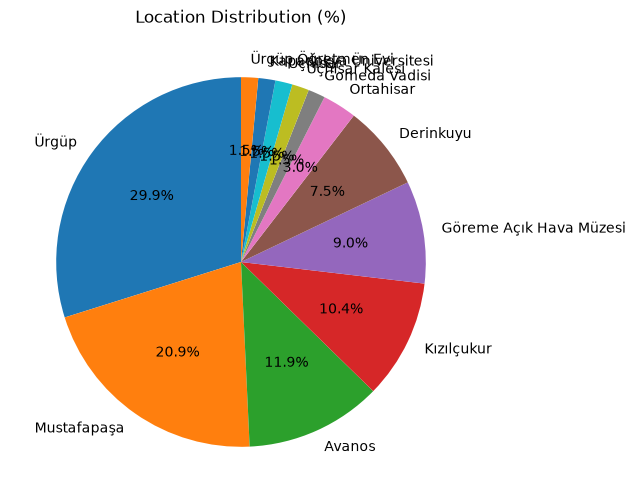

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    location_counts,
    labels=location_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Location Distribution (%)")

plt.show()

### Observation

Pie chart, veri setindeki her konumun toplam veri seti içerisindeki oranını göstermektedir. Bu analiz sayesinde belirli bölgelerin aşırı temsil edilip edilmediği veya bazı bölgelerin eksik temsil edildiği kolayca değerlendirilebilir.

In [ ]:
location_table = location_counts.reset_index()

location_table.columns = ["Location", "Image Count"]

location_table

,Location,Image Count
0,Ürgüp,20
1,Mustafapaşa,14
2,Avanos,8
3,Kızılçukur,7
4,Göreme Açık Hava Müzesi,6
5,Derinkuyu,5
6,Ortahisar,2
7,Gomeda Vadisi,1
8,Uçhisar Kalesi,1
9,Uçhisar,1


In [ ]:
location_table["Percentage"] = (
    location_table["Image Count"]
    / location_table["Image Count"].sum()
    *100
).round(2)

location_table

,Location,Image Count,Percentage
0,Ürgüp,20,29.85
1,Mustafapaşa,14,20.90
2,Avanos,8,11.94
3,Kızılçukur,7,10.45
4,Göreme Açık Hava Müzesi,6,8.96
5,Derinkuyu,5,7.46
6,Ortahisar,2,2.99
7,Gomeda Vadisi,1,1.49
8,Uçhisar Kalesi,1,1.49
9,Uçhisar,1,1.49


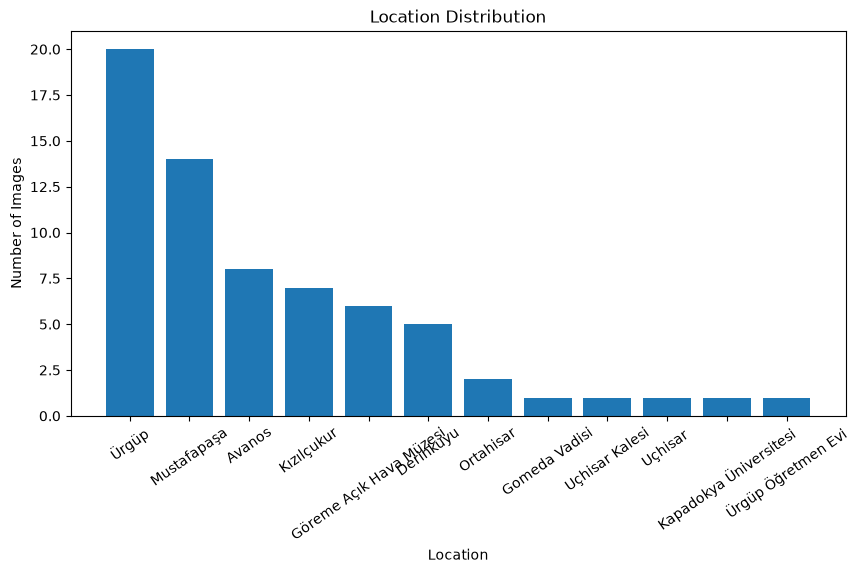

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    location_table["Location"],
    location_table["Image Count"]
)

plt.title("Location Distribution")

plt.xlabel("Location")

plt.ylabel("Number of Images")

plt.xticks(rotation=35)

plt.show()

## Interpretation

Grafik incelendiğinde referans veri setinin en fazla Ürgüp ve Mustafapaşa bölgelerinden oluştuğu görülmektedir. Avanos, Kızılçukur ve Göreme bölgeleri de veri setinde temsil edilmektedir. Buna karşın bazı bölgeler yalnızca birkaç örnek ile temsil edildiğinden veri setinde bölgesel dengesizlik bulunduğu söylenebilir.

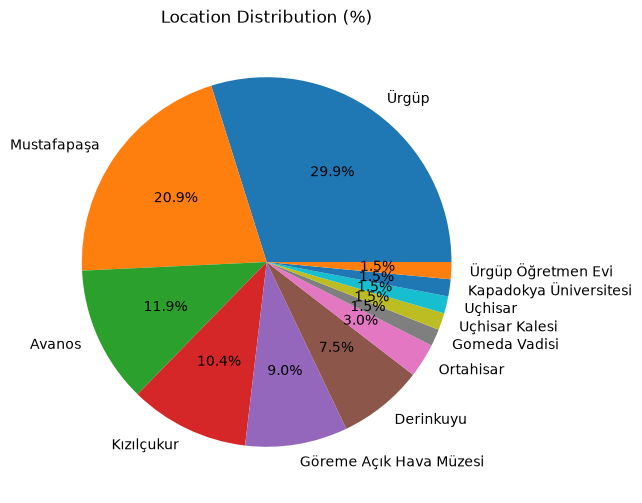

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    location_table["Image Count"],
    labels=location_table["Location"],
    autopct="%1.1f%%"
)

plt.title("Location Distribution (%)")

plt.show()

### Observation

Pie chart, veri setindeki konumların toplam veri seti içerisindeki yüzdesel dağılımını göstermektedir. Bu analiz, hangi bölgelerin baskın şekilde temsil edildiğini ve gelecekte veri setinin hangi bölgelerden yeni örneklerle zenginleştirilebileceğini göstermektedir.

# Reference Dataset Analysis

## Dataset Summary

Bu bölümde CHRD-Real referans veri setinin genel özellikleri özetlenmektedir. Amaç veri setinin büyüklüğünü, çeşitliliğini ve kültürel temsil gücünü ortaya koymaktır.

In [ ]:
summary = {
    "Total Images": len(metadata),
    "Unique Themes": metadata["theme"].nunique(),
    "Unique Locations": metadata["location"].nunique(),
    "Unique Motif 1": metadata["motif_1"].nunique(),
    "Unique Motif 2": metadata["motif_2"].nunique()
}

summary

{'Total Images': 188,
 'Unique Themes': 11,
 'Unique Locations': 12,
 'Unique Motif 1': 23,
 'Unique Motif 2': 23}

## Observation

Referans veri seti toplam görsel sayısı, tema çeşitliliği, konum çeşitliliği ve kültürel motif çeşitliliği açısından incelenmiştir. Bu özet veri setinin genel kapsamını göstermektedir.

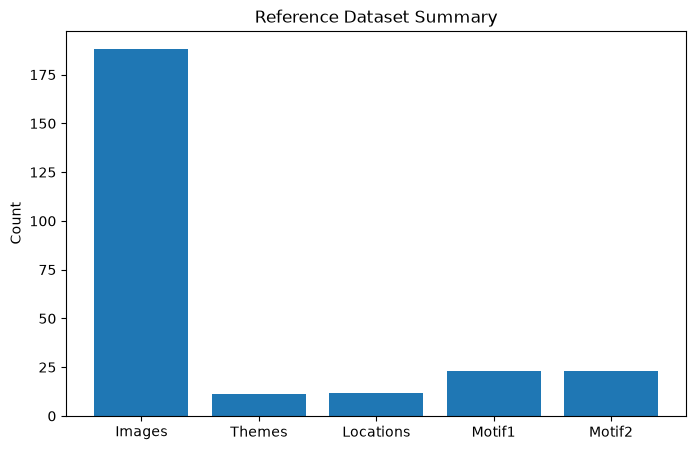

In [ ]:
summary_values = [
    len(metadata),
    metadata["theme"].nunique(),
    metadata["location"].nunique(),
    metadata["motif_1"].nunique(),
    metadata["motif_2"].nunique()
]

summary_labels = [
    "Images",
    "Themes",
    "Locations",
    "Motif1",
    "Motif2"
]

plt.figure(figsize=(8,5))

plt.bar(summary_labels, summary_values)

plt.title("Reference Dataset Summary")

plt.ylabel("Count")

plt.show()

## Interpretation

Grafik, referans veri setinin genel yapısını özetlemektedir. Görsel sayısı kültürel kategori sayısından oldukça yüksektir. Bu durum aynı kültürel ögelerin farklı örneklerle temsil edildiğini göstermektedir. Aynı zamanda tema ve motif çeşitliliği veri setinin kültürel kapsamının geniş olduğunu ortaya koymaktadır.

In [ ]:
quality_table = pd.DataFrame({

    "Metric":[
        "Total Images",
        "Theme Diversity",
        "Location Diversity",
        "Primary Motifs",
        "Secondary Motifs"
    ],

    "Value":[
        len(metadata),
        metadata["theme"].nunique(),
        metadata["location"].nunique(),
        metadata["motif_1"].nunique(),
        metadata["motif_2"].nunique()
    ]

})

quality_table

,Metric,Value
0,Total Images,188
1,Theme Diversity,11
2,Location Diversity,12
3,Primary Motifs,23
4,Secondary Motifs,23


### Dataset Quality Assessment

Bu tablo referans veri setinin temel kalite göstergelerini özetlemektedir. Veri setinin yalnızca görsel sayısı değil aynı zamanda tema, motif ve konum çeşitliliği de değerlendirilmektedir.

## Veri Setini Filtreleme


In [31]:
selected_themes = [
    "Local Architecture",
    "Daily Life",
    "Rock-cut Heritage",
    "Natural Landscape",
    "Village Square",
    "Fairy Chimney"
]

df_selected = df[df["theme"].isin(selected_themes)]

print(df_selected["theme"].value_counts())

theme
Local Architecture    51
Daily Life            37
Rock-cut Heritage     27
Natural Landscape     20
Village Square        18
Fairy Chimney         11
Name: count, dtype: int64


In [33]:
print(df_selected.shape)

(164, 11)


In [34]:
df_selected.head(10)

,image_id,file_name,theme,location,motif_1,motif_2,season,contains_people,quality_score,cultural_value,notes
0,CHRD_REAL_0001,CHRD_REAL_0001.jpeg,Rock-cut Heritage,Ürgüp,Cave House,Stone House,Summer,No,NaN,High,NaN
3,CHRD_REAL_0004,CHRD_REAL_0004.jpeg,Village Square,Ürgüp,Street,Local People,Summer,No,NaN,Medium,NaN
4,CHRD_REAL_0005,CHRD_REAL_0005.jpeg,Fairy Chimney,NaN,Rock Formation,Balloon,Summer,No,NaN,High,NaN
5,CHRD_REAL_0006,CHRD_REAL_0006.jpeg,Local Architecture,NaN,Church,Monastery,Summer,No,NaN,Low,NaN
6,CHRD_REAL_0007,CHRD_REAL_0007.jpeg,Daily Life,NaN,Stone House,Street,Summer,No,NaN,Medium,NaN
7,CHRD_REAL_0008,CHRD_REAL_0008.jpeg,Local Architecture,NaN,Rock Formation,Stone House,Summer,No,NaN,High,NaN
8,CHRD_REAL_0009,CHRD_REAL_0009.jpeg,Daily Life,NaN,Stone House,Pottery,Summer,No,NaN,High,NaN
10,CHRD_REAL_0011,CHRD_REAL_0011.jpeg,Natural Landscape,NaN,Sunrise,Balloon,Summer,No,NaN,High,NaN
13,CHRD_REAL_0014,CHRD_REAL_0014.jpeg,Daily Life,NaN,Valley,Rock Formation,Summer,No,NaN,High,NaN
14,CHRD_REAL_0015,CHRD_REAL_0015.jpeg,Village Square,NaN,Rock Formation,Landscape,NaN,No,NaN,Low,NaN


In [35]:
df_selected.to_csv(
    "../data/CHRD_Real/metadata_selected.csv",
    index=False,
    sep=";"
)

# Veri Kümesinin Çalışma Temalarına Göre Filtrelenmesi

Bu çalışmada kültürel çeşitliliğin yeterli düzeyde temsil edilebilmesi amacıyla veri kümesindeki tüm temalar kullanılmamıştır.

İlk analiz sonucunda bazı temalarda yeterli sayıda görsel bulunmadığı görülmüştür (örneğin Winter, Sunrise ve Valley).

Bu nedenle veri kümesi, hem kültürel çeşitliliği temsil eden hem de yeterli örnek sayısına sahip olan altı temel tema ile sınırlandırılmıştır.

Seçilen temalar:

- Local Architecture
- Daily Life
- Rock-cut Heritage
- Natural Landscape
- Village Square
- Fairy Chimney

Bu filtreleme işlemi, sonraki aşamalarda gerçekleştirilecek üretim, karşılaştırma ve değerlendirme süreçlerinde sınıflar arasındaki dengenin korunmasını amaçlamaktadır.

In [36]:
# Kullanılacak temaların listesi

selected_themes = [
    "Local Architecture",
    "Daily Life",
    "Rock-cut Heritage",
    "Natural Landscape",
    "Village Square",
    "Fairy Chimney"
]

# Sadece bu temaları seç

filtered_df = df[df["theme"].isin(selected_themes)]

print("Toplam görsel sayısı:", len(filtered_df))

Toplam görsel sayısı: 164


## Filtrelenmiş Tema Dağılımı

Filtreleme işleminden sonra veri kümesindeki tema dağılımı tekrar incelenmiştir.

Bu grafik, çalışmada kullanılacak altı ana kültürel temanın veri kümesindeki örnek sayılarını göstermektedir.

Bu analiz sayesinde herhangi bir temanın aşırı temsil edilip edilmediği gözlemlenebilmektedir.

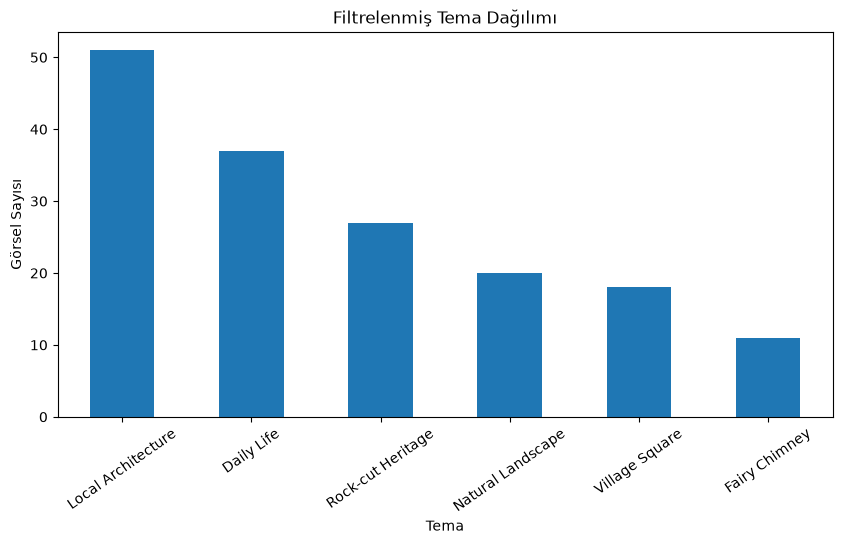

In [37]:
import matplotlib.pyplot as plt

theme_counts = filtered_df["theme"].value_counts()

plt.figure(figsize=(10,5))

theme_counts.plot(kind="bar")

plt.title("Filtrelenmiş Tema Dağılımı")
plt.xlabel("Tema")
plt.ylabel("Görsel Sayısı")

plt.xticks(rotation=35)

plt.show()

## Filtrelenmiş Veri Kümesinin Kaydedilmesi

Filtreleme işlemi tamamlandıktan sonra yeni veri kümesi ayrı bir dosya olarak kaydedilmiştir.

Bu sayede sonraki analizlerde tekrar filtreleme yapılmasına gerek kalmadan aynı veri kümesi kullanılabilecektir.

In [38]:
filtered_df.to_csv(
    "../data/CHRD_Real/metadata_filtered.csv",
    index=False,
    encoding="utf-8-sig"
)

print("metadata_filtered.csv oluşturuldu.")

metadata_filtered.csv oluşturuldu.


# Lokasyon Dağılımının İncelenmesi

Bu bölümde referans veri kümesinde yer alan görsellerin Kapadokya'nın hangi bölgelerinden toplandığı analiz edilmektedir.

Lokasyon çeşitliliği, veri kümesinin yalnızca belirli bir turistik noktaya odaklanmasını engelleyerek kültürel temsil gücünü artırmaktadır.

Bu analiz sayesinde hangi ilçelerin veya bölgelerin veri kümesinde daha fazla temsil edildiği belirlenmektedir.

Daha sonraki deneylerde üretilecek yapay görseller de aynı lokasyonlara ait istemlerle üretileceği için bu dağılım önemlidir.

location
Ürgüp                      18
Mustafapaşa                11
Avanos                      6
Derinkuyu                   5
Göreme Açık Hava Müzesi     5
Kızılçukur                  5
Ortahisar                   2
Uçhisar Kalesi              1
Uçhisar                     1
Kapadokya Üniversitesi      1
Ürgüp Öğretmen Evi          1
Name: count, dtype: int64


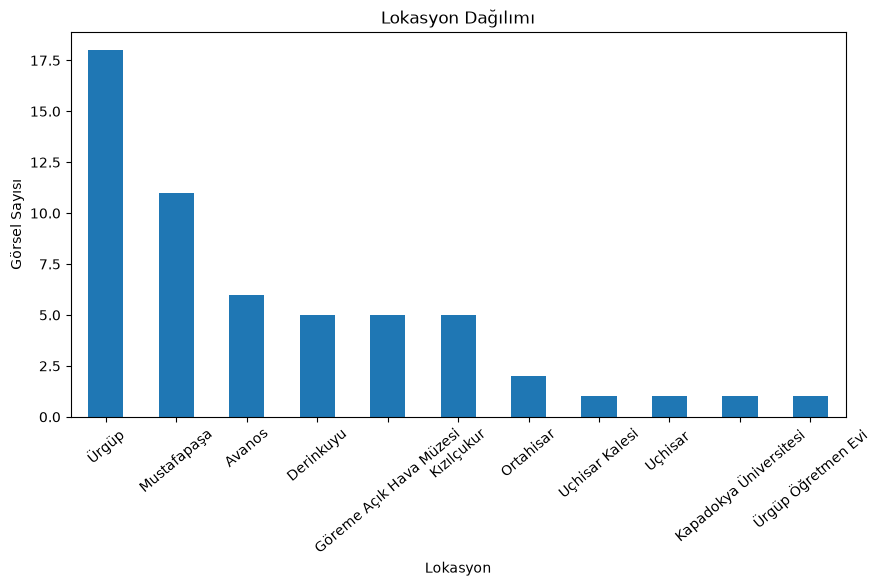

In [39]:
import matplotlib.pyplot as plt

location_counts = filtered_df["location"].value_counts()

print(location_counts)

plt.figure(figsize=(10,5))

location_counts.plot(kind="bar")

plt.title("Lokasyon Dağılımı")

plt.xlabel("Lokasyon")

plt.ylabel("Görsel Sayısı")

plt.xticks(rotation=40)

plt.show()

## Analizin Yorumu

Grafik incelendiğinde referans veri kümesinin Kapadokya'nın farklı bölgelerini kapsadığı görülmektedir.

Bazı lokasyonlar diğerlerine göre daha fazla temsil edilmektedir.

Bu durum gerçek hayatta daha fazla fotoğrafın bu bölgelerde bulunmasından kaynaklanmaktadır.

Veri kümesi yalnızca tek bir lokasyona bağlı kalmadığından kültürel çeşitlilik açısından yeterli düzeyde temsil sağlamaktadır.

# Kültürel Motif Dağılımı

Her görsel yalnızca tema bilgisi ile değil aynı zamanda kültürel motifler açısından da etiketlenmiştir.

Motifler, Kapadokya'nın mimari, doğal ve kültürel karakterini oluşturan temel görsel ögeleri temsil etmektedir.

Bu bölümde veri kümesinde en sık görülen motifler analiz edilmektedir.

Analiz sırasında birinci ve ikinci motif sütunları birlikte değerlendirilmektedir.

In [40]:
motifs = pd.concat([
    filtered_df["motif_1"],
    filtered_df["motif_2"]
])

motifs = motifs.dropna()

motif_counts = motifs.value_counts()

print(motif_counts)

Stone House           53
Rock Formation        39
Street                23
Museum                23
Landscape             22
Fairy Chimney         21
Hot Air Balloon       15
cave house            15
Cave House            13
Church                12
Valley                10
Airship               10
Sunrise                6
landscape              6
River                  5
cave hotel             4
Pottery                4
Local People           2
trees                  2
Balloon                2
sunset                 2
Local Architecture     1
snow                   1
Ballon                 1
rock Formation         1
Monastery              1
Agriculture            1
sky                    1
carpet                 1
Name: count, dtype: int64


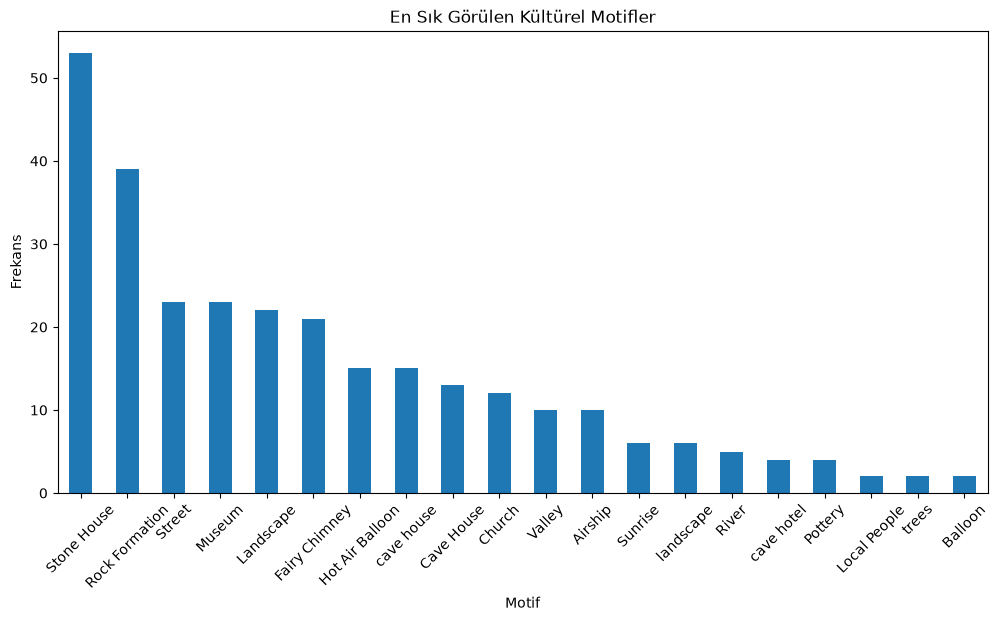

In [41]:
plt.figure(figsize=(12,6))

motif_counts.head(20).plot(kind="bar")

plt.title("En Sık Görülen Kültürel Motifler")

plt.xlabel("Motif")

plt.ylabel("Frekans")

plt.xticks(rotation=45)

plt.show()